In [2]:
from eregion.tasks.imagegen import ImageCreator
from eregion.tasks.custom import load_image_fits_KPF
import numpy as np
import matplotlib.pyplot as plt
import eregion.core.welch2d as welch2d
from scipy.signal.windows import hamming, hann


In [3]:
imtask = ImageCreator(detector_config='../src/eregion/configs/detectors/kpf.yaml')
res = imtask.run(input_source='../data/KPF/KP.20250219.590*.fits', fileloader_func=load_image_fits_KPF)
kpfdat = res.data
kpfdat

2026-09-23 01:47:38,845 - DetectorConfig - INFO - Config loaded from file '../src/eregion/configs/detectors/kpf.yaml'
2026-09-23 01:47:38,846 - image_creator - INFO - Item ../data/KPF/KP.20250219.590*.fits is a glob pattern


,type,exptime,det_id,filename,object
0,slewcal,60.0,green,../data/KPF/KP.20250219.59086.42.fits,<eregion.datamodels.image.DetImage object at 0...
1,slewcal,60.0,red,../data/KPF/KP.20250219.59086.42.fits,<eregion.datamodels.image.DetImage object at 0...
2,OBJECT,0.0,cahk,../data/KPF/KP.20250219.59086.42.fits,<eregion.datamodels.image.DetImage object at 0...


<Axes: xlabel='x', ylabel='y'>

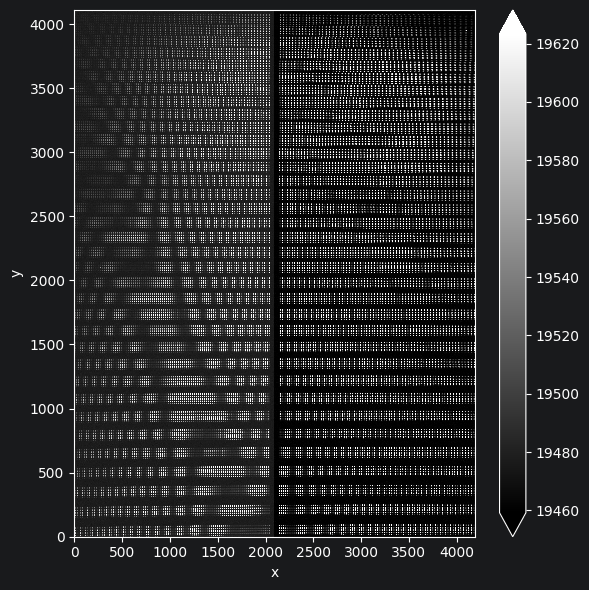

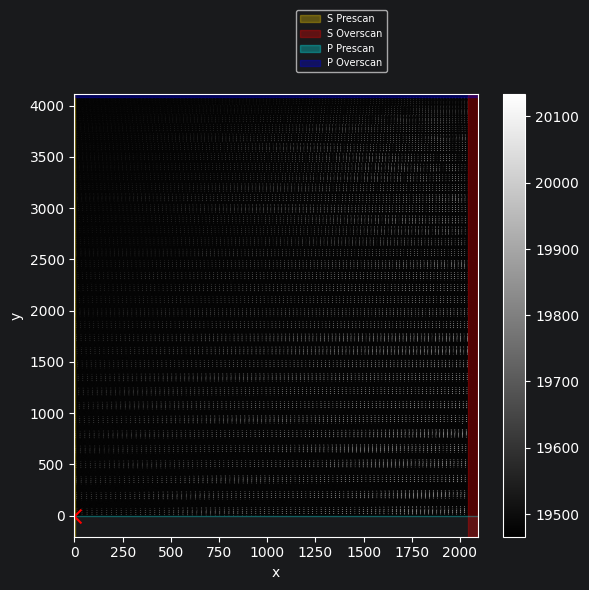

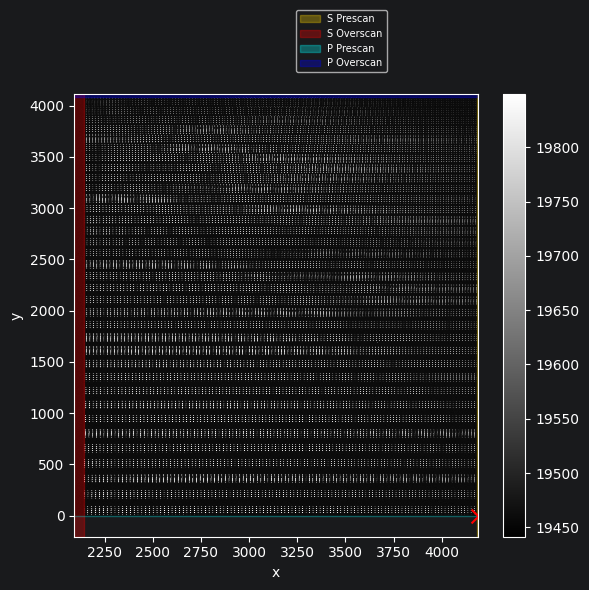

In [4]:
green = kpfdat[0]
vmin, vmax = np.percentile(green.data.values, [5, 95])
ax = green.show(cmap='gray', with_mask=False, vmin=vmin, vmax=vmax)

leftchan = green.outputs['amp1']
leftchan.show(cmap='gray', shade_regions=True)

rightchan = green.outputs['amp2']
rightchan.show(cmap='gray', shade_regions=True)

In [5]:
# row size / pixel clock freq + parallel shift time -> T_line
t_line = (2094/200 + 90e-3 * 7) * 1e-3 # seconds

def plot_psd(psd, f_pix=2e5, t_line=0.0111, figsize=(6, 6), log_image=True, zscale=True, in_hertz=False):
    fig, ax = plt.subplots(2, 2, figsize=figsize, width_ratios=[3, 1], height_ratios=[3, 1])
    fig.subplots_adjust(wspace=0.05, hspace=0.05)

    # symmetric frequency axes for the 2D PSD plot
    ny, nx = psd.shape
    # Generate matching frequency arrays for the 1D marginal line plots
    freq_x = np.linspace(-0.5, 0.5, nx)
    freq_y = np.linspace(-0.5, 0.5, ny)
    if in_hertz:
        freq_x *= f_pix / 1e3 # kHz
        freq_y /= t_line # Hz

    shiftedpsd = np.fft.fftshift(psd)
    plotimg = np.log(shiftedpsd) if log_image else shiftedpsd
    if zscale:
        vmin, vmax = np.percentile(plotimg, [5, 95])
    else:
        vmin, vmax = None, None

    im = ax[0,0].imshow(plotimg, origin='lower', vmin=vmin, vmax=vmax, cmap='magma', extent=[-0.5, 0.5, -0.5, 0.5])
    pos = ax[0,0].get_position()
    cax = fig.add_axes([pos.x0, pos.y1 + 0.02, pos.width, 0.03])
    cax.axis('off')
    cax.tick_params(labelsize=8)
    fig.colorbar(im, ax=cax, location='top', fraction=0.9)

    ax[0,1].plot(np.sum(shiftedpsd, axis=1), freq_y, color='pink')
    ax[1,0].plot(freq_x, np.sum(shiftedpsd, axis=0), color='pink')

    ax[0,1].set_xscale('log')
    ax[1,0].set_yscale('log')
    ax[0,1].yaxis.tick_right()
    ax[1,1].axis('off')
    if in_hertz:
        ax[1,0].sharex(ax[0,0])
        ax[0,1].sharey(ax[0,0])
    ax[0,0].tick_params(labelbottom=False)

    # Force symmetric ticks at clean steps (e.g., -0.5, -0.25, 0, 0.25, 0.5)
    x_unit = "kHz" if in_hertz else "cycles/pixel"
    y_unit = "Hz" if in_hertz else "cycles/row"
    ax[1,0].set_xlabel(f"Horizontal Frequency ({x_unit})", fontsize=9)
    ax[0,1].set_ylabel(f"Vertical Frequency ({y_unit})", fontsize=9)
    ax[0,1].yaxis.set_label_position("right")
    return fig, ax


Text(0.5, 1.0, 'Green CCD, Right Amp')

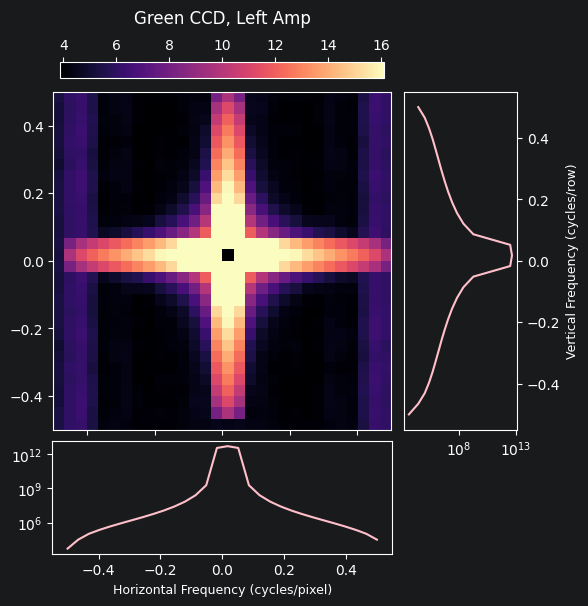

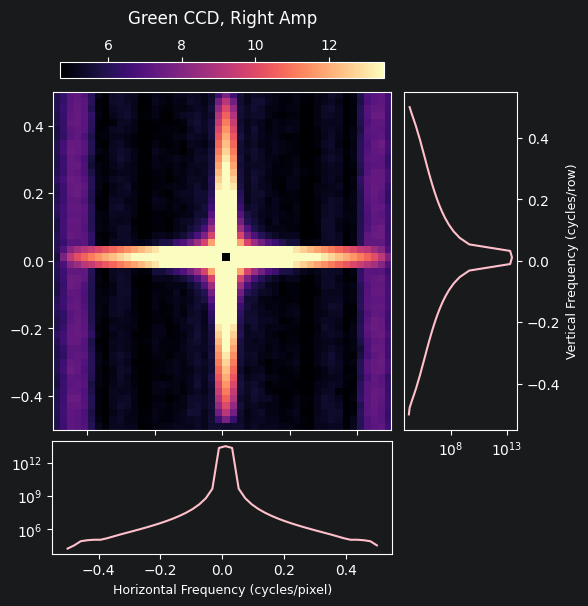

In [6]:
green = kpfdat[0]

# limage, _ = green.outputs['amp1'].get_image_region()
limage = green.outputs['amp1'].get_overscan(axis='serial', corner=False)
psd, d_psd = welch2d.welch2d(limage.values[:,5:45], target_shape=30, window_func=hamming, subtract_dc=True)
fig, ax = plot_psd(psd, figsize=(6,6))
plt.title('Green CCD, Left Amp', pad=40)

# rimage, _ = green.outputs['amp2'].get_image_region()
rimage = green.outputs['amp2'].get_overscan(axis='serial', corner=False)
psd, d_psd = welch2d.welch2d(rimage.values, target_shape=48, window_func=hamming, subtract_dc=True)
fig, ax = plot_psd(psd, figsize=(6,6))
plt.title('Green CCD, Right Amp', pad=40)

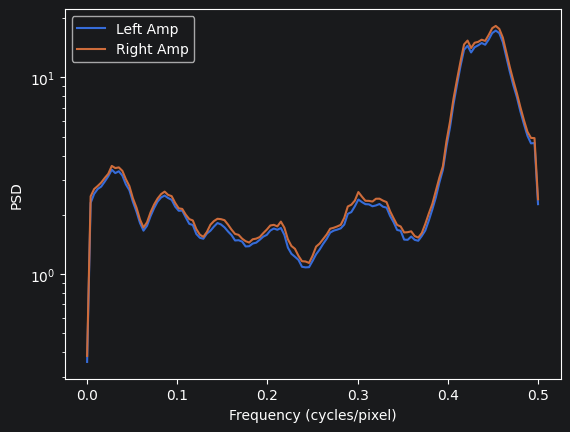

In [7]:
from scipy.signal import welch

fl, psdl = welch2d.raveled_welch(limage.values, target_shape=256, window_func='hamming')
fr, psdr = welch2d.raveled_welch(rimage.values, target_shape=256, window_func='hamming')

plt.plot(fl, psdl, label='Left Amp')
plt.plot(fr, psdr, label='Right Amp')
plt.yscale('log')
plt.ylabel('PSD')
plt.xlabel('Frequency (cycles/pixel)')
plt.legend()

## DEIMOS noise analysis

In [8]:
from eregion.tasks.custom import guess_image_type_from_filename_DEIMOS, load_image_fits_DEIMOS

creator = ImageCreator(detector_config = '../src/eregion/configs/detectors/deimos_sci.yaml')
res2 = creator.run(input_source = '/Users/yashvi/Desktop/Detector Characterization Tools/DTU_dettest/DTU_fullfp_bringup/bintest/SCI/20260722-171930/*SCI_1_bias_0_2026*.fits',
                  identifier_func = guess_image_type_from_filename_DEIMOS,
                  fileloader_func = load_image_fits_DEIMOS,
                  data_on_demand = True)
dedat = res2.data
dedat

2026-09-23 01:49:47,153 - DetectorConfig - INFO - Config loaded from file '../src/eregion/configs/detectors/deimos_sci.yaml'
2026-09-23 01:49:47,153 - DetectorConfig - INFO - Config loaded from file '../src/eregion/configs/detectors/deimos_sci.yaml'
2026-09-23 01:49:47,154 - image_creator - INFO - Item /Users/yashvi/Desktop/Detector Characterization Tools/DTU_dettest/DTU_fullfp_bringup/bintest/SCI/20260722-171930/*SCI_1_bias_0_2026*.fits is a glob pattern
2026-09-23 01:49:47,154 - image_creator - INFO - Item /Users/yashvi/Desktop/Detector Characterization Tools/DTU_dettest/DTU_fullfp_bringup/bintest/SCI/20260722-171930/*SCI_1_bias_0_2026*.fits is a glob pattern


,type,exptime,obstime,seqnum,led,backbias,det_id,filename,object
0,bias,0.0,2026-07-22T171946.612,0,GREEN,-60.0,det_1,/Users/yashvi/Desktop/Detector Characterizatio...,<eregion.datamodels.image.DetImage object at 0...


Text(0.5, 1.0, 'DEIMOS SCI-1, Amp F')

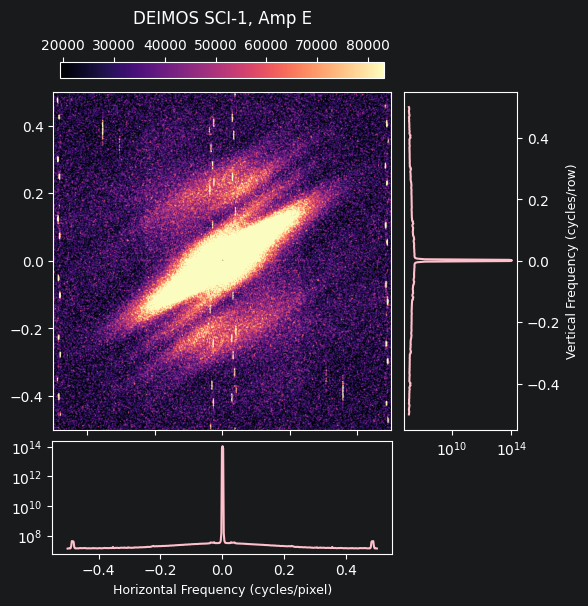

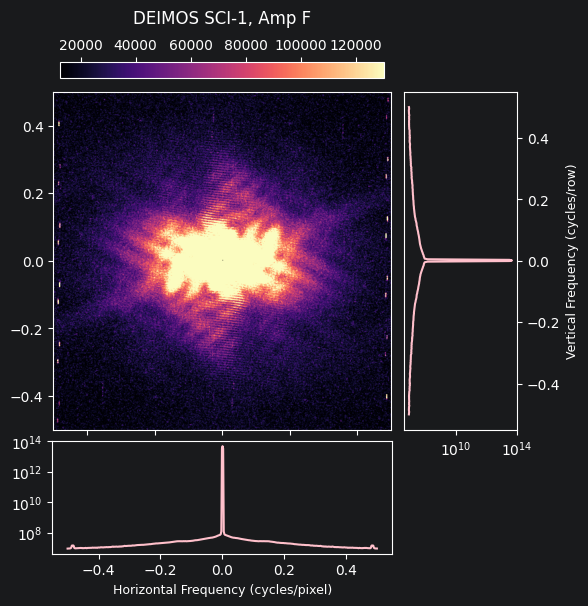

In [9]:
img = dedat[0]

limage = img.outputs['E'].data
psd, d_psd = welch2d.welch2d(limage.values, target_shape=512, window_func=hamming, subtract_dc=True)
fig, ax = plot_psd(psd, figsize=(6,6), zscale=True, log_image=False)
plt.title(f'DEIMOS SCI-1, Amp E', pad=40)

rimage = img.outputs['F'].data
# rimage = img.outputs['F'].get_overscan('serial',corner=False)
psd, d_psd = welch2d.welch2d(rimage.values, target_shape=512, window_func=hamming, subtract_dc=True)
fig, ax = plot_psd(psd, figsize=(6,6), zscale=True, log_image=False)
plt.title(f'DEIMOS SCI-1, Amp F', pad=40)

Text(0.5, 1.0, 'DEIMOS SCI-1, Amp F')

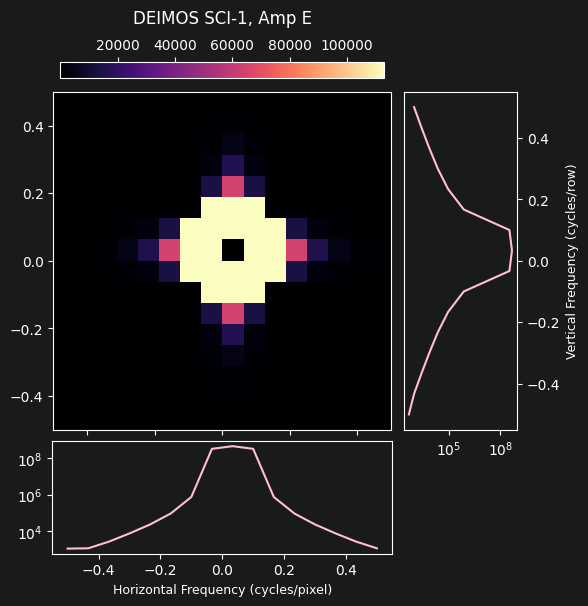

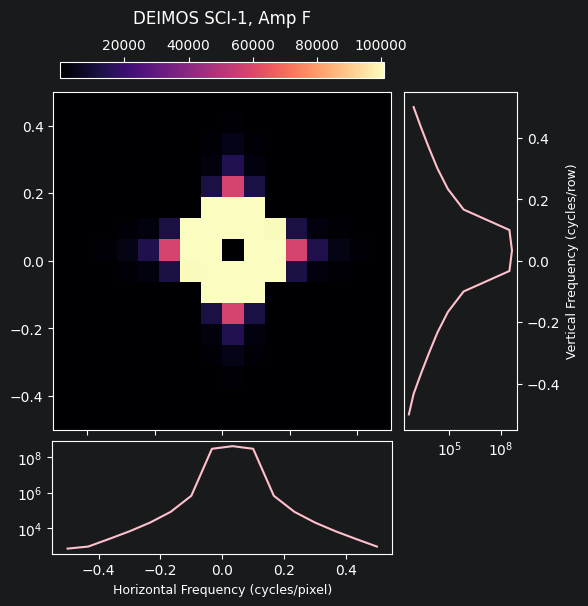

In [10]:
limage = img.outputs['E'].get_overscan('serial',corner=False)
psd, d_psd = welch2d.welch2d(limage.values, target_shape=16, window_func=hamming, subtract_dc=True)
fig, ax = plot_psd(psd, figsize=(6,6), zscale=True, log_image=False)
plt.title(f'DEIMOS SCI-1, Amp E', pad=40)

rimage = img.outputs['F'].get_overscan('serial',corner=False)
psd, d_psd = welch2d.welch2d(rimage.values, target_shape=16, window_func=hamming, subtract_dc=True)
fig, ax = plot_psd(psd, figsize=(6,6), zscale=True, log_image=False)
plt.title(f'DEIMOS SCI-1, Amp F', pad=40)

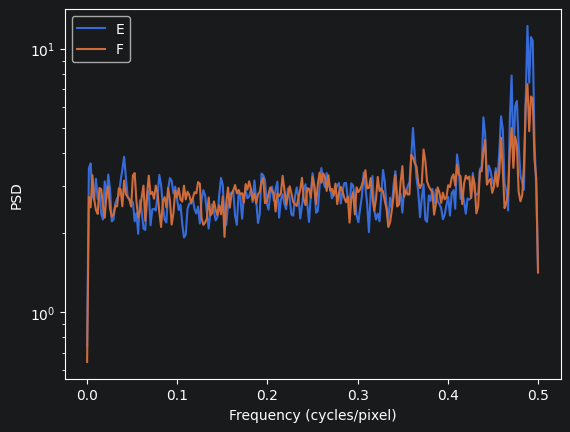

In [11]:
fl, psdl = welch2d.raveled_welch(limage.values[:,10:], 512, window_func='hann')
fr, psdr = welch2d.raveled_welch(rimage.values[:,10:], 512, window_func='hann')
plt.plot(fl, psdl, label='E')
plt.plot(fr, psdr, label='F')
plt.yscale('log')
plt.ylabel('PSD')
plt.xlabel('Frequency (cycles/pixel)')
plt.legend()

Mostly 1D is needed, 2D is useful for visualizing.

Read only overscans data.

Pre-CDS data analysis.

Live plotting tool, with speech to text annotation.

noise in large font

audacity waterfall plot with live update



total noise - std dev in overscan region

raveled welch one direction (overscan, image)

noise over time for image series (maybe with live tagging)

overscan histogram
